# Flight Dataset — Data Visualization
Saint-Exupery Airport | `database.db`

## 1. Import libraries

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats
import os, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
print('Libraries ready')

Libraries ready


In [2]:
OUT_DIR = Path(os.getcwd()) / 'outputs' / 'viz'
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output folder: {OUT_DIR}')


Output folder: c:\Users\ACER\Documents\GitHub\master-minds-challenge\outputs\viz


## 2. Load data

In [3]:
_here = Path(os.getcwd())
DB_PATH = _here / 'database.db'
if not DB_PATH.exists():
    DB_PATH = _here / 'Procedure_data' / 'insa' / 'database.db'

print(f'DB path : {DB_PATH}')
print(f'Exists  : {DB_PATH.exists()}')

conn = sqlite3.connect(str(DB_PATH))
df = pd.read_sql_query('SELECT * FROM mouvements_aero_insa', conn)
conn.close()

df['LTScheduledDatetime'] = pd.to_datetime(df['LTScheduledDatetime'], errors='coerce')
df['Month']   = df['LTScheduledDatetime'].dt.to_period('M').astype(str)
df['Hour']    = df['LTScheduledDatetime'].dt.hour
df['Weekday'] = df['LTScheduledDatetime'].dt.day_name()

print(f'Loaded {len(df):,} rows x {df.shape[1]} columns')
df.head(2)


DB path : c:\Users\ACER\Documents\GitHub\master-minds-challenge\database.db
Exists  : True
Loaded 364,623 rows x 198 columns


,IdMovementVinci,IdFarms,IdMovement,IdADL,IdPkgStand,IdTraficType,IdIrregularityCode,IdRunway,IdAircraftType,IdBusinessUnitType,...,PxScansAccPIF,PxScansPIF,PxScansRX,PxScansGAT,PxScansSalonConfluence,PxScansSalonMontblanc,etl_origin,Month,Hour,Weekday
0,NULL,NULL,20260701195500MAC00341,20260701195500MAC00341,NULL,2,NULL,NULL,320,1,...,NULL,NULL,NULL,NULL,NULL,NULL,Cohor,2026-07,19,Wednesday
1,NULL,NULL,20260422224500MAC00344,20260422224500MAC00344,NULL,2,NULL,NULL,320,1,...,NULL,NULL,NULL,NULL,NULL,NULL,Cohor,2026-04,22,Wednesday


## 3. Overview

In [4]:
print(f'Rows    : {len(df):,}')
print(f'Columns : {df.shape[1]}')
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).to_string())
print('\n=== Numeric Statistics ===')
df.describe(include=[np.number]).round(2)

Rows    : 364,623
Columns : 198

=== Missing Values ===
Series([], )

=== Numeric Statistics ===


,IdTraficType,IdBusinessUnitType,IdBusContactType,IdTerminalType,IdBagStatusDelivery,NbFlight,Hour
count,364623.00,364623.00,364623.00,364623.00,364623.00,364623.0,364623.00
mean,1.12,1.25,2.08,0.92,2.31,1.0,13.92
std,0.42,1.09,1.09,0.27,0.95,0.0,5.15
min,0.00,1.00,0.00,0.00,1.00,1.0,0.00
25%,1.00,1.00,1.00,1.00,1.00,1.0,10.00
50%,1.00,1.00,3.00,1.00,3.00,1.0,14.00
75%,1.00,1.00,3.00,1.00,3.00,1.0,18.00
max,2.00,10.00,3.00,1.00,3.00,1.0,23.00


## 4. Arrivals vs departures

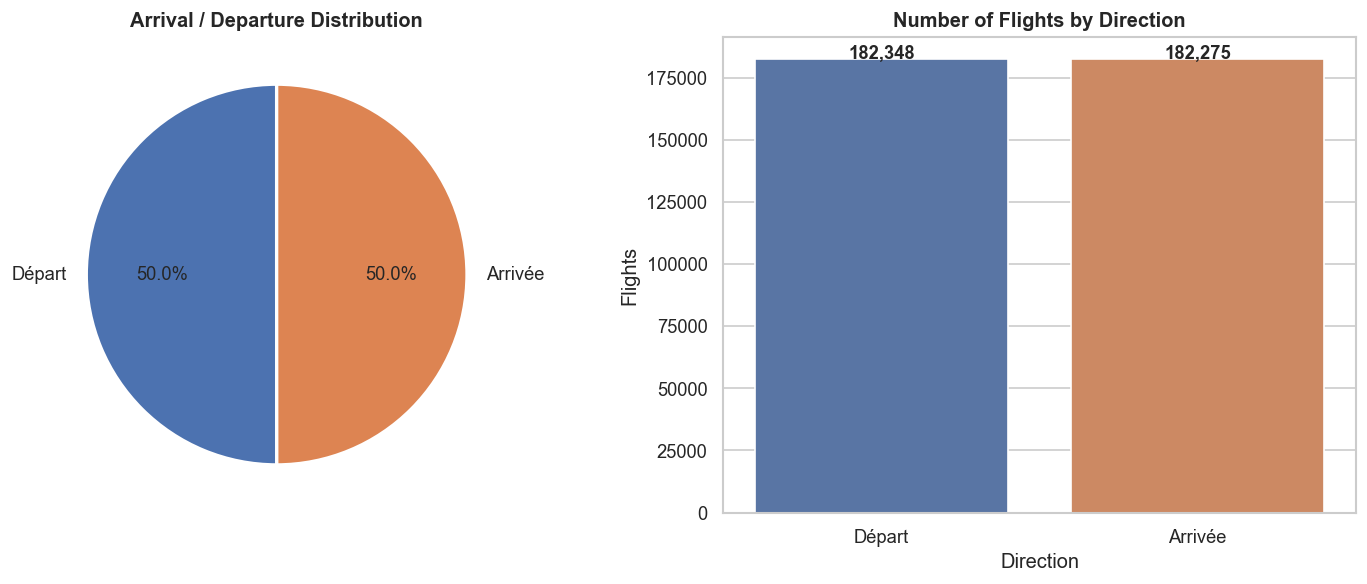

In [5]:
dir_counts = df['Direction'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(dir_counts, labels=dir_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Arrival / Departure Distribution', fontweight='bold')
sns.barplot(x=dir_counts.index, y=dir_counts.values,
            palette=['#4C72B0','#DD8452'], ax=axes[1])
axes[1].set_title('Number of Flights by Direction', fontweight='bold')
axes[1].set_xlabel('Direction'); axes[1].set_ylabel('Flights')
for i, v in enumerate(dir_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '01_arrivals_vs_departures.png', bbox_inches='tight', dpi=150)
plt.show()


## 5. Top 15 airlines

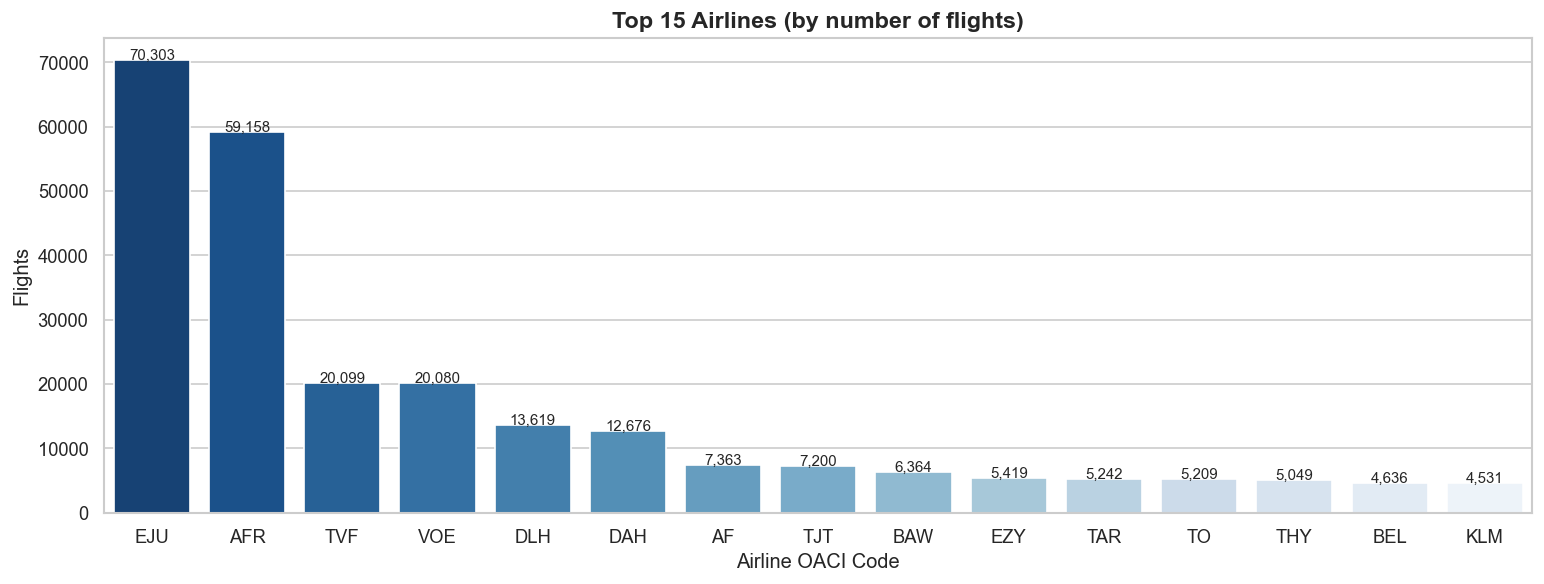

In [6]:
top_airlines = df['airlineOACICode'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(x=top_airlines.index, y=top_airlines.values, palette='Blues_r', ax=ax)
ax.set_title('Top 15 Airlines (by number of flights)', fontsize=14, fontweight='bold')
ax.set_xlabel('Airline OACI Code'); ax.set_ylabel('Flights')
for i, v in enumerate(top_airlines.values):
    ax.text(i, v + 80, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / '02_top_airlines.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Flights per month

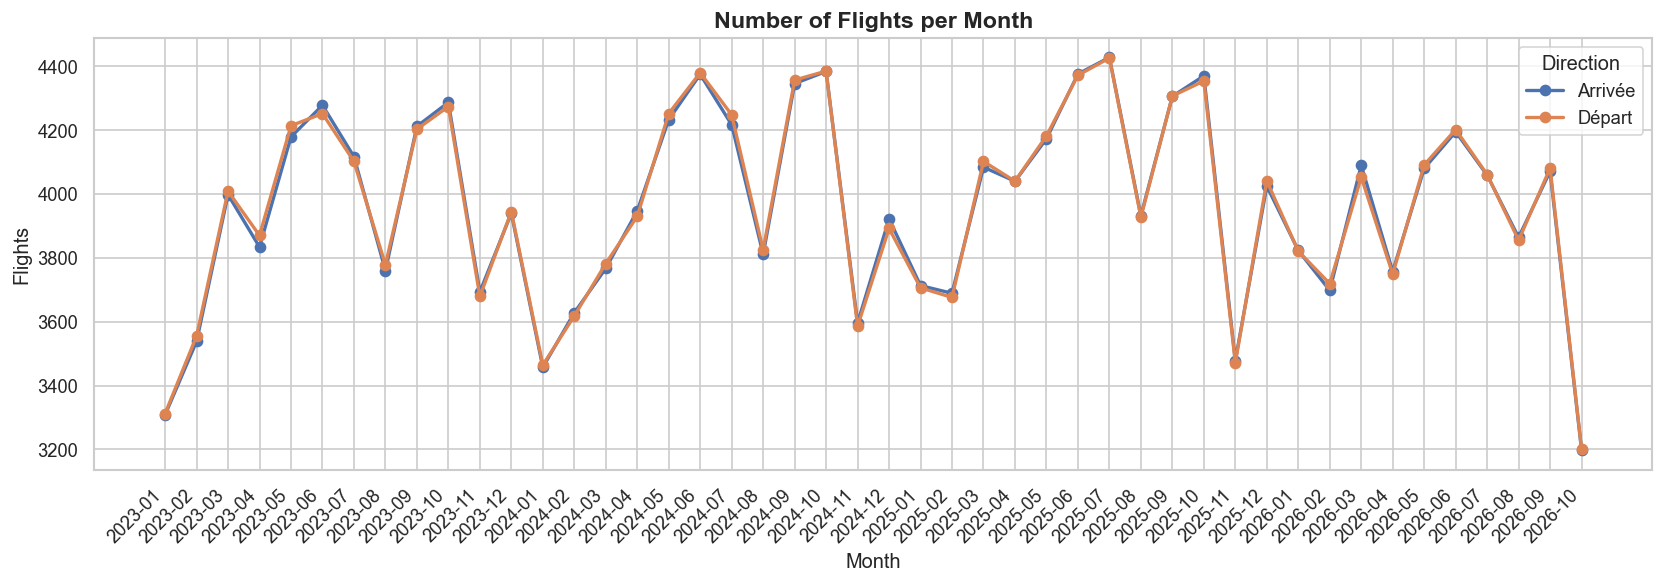

In [7]:
monthly = df.groupby(['Month','Direction']).size().reset_index(name='count').sort_values('Month')
fig, ax = plt.subplots(figsize=(14, 5))
for direction, grp in monthly.groupby('Direction'):
    ax.plot(grp['Month'], grp['count'], marker='o', label=direction, linewidth=2)
ax.set_title('Number of Flights per Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Flights'); ax.legend(title='Direction')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(OUT_DIR / '03_flights_per_month.png', bbox_inches='tight', dpi=150)
plt.show()


## 7. Flights by hour of day

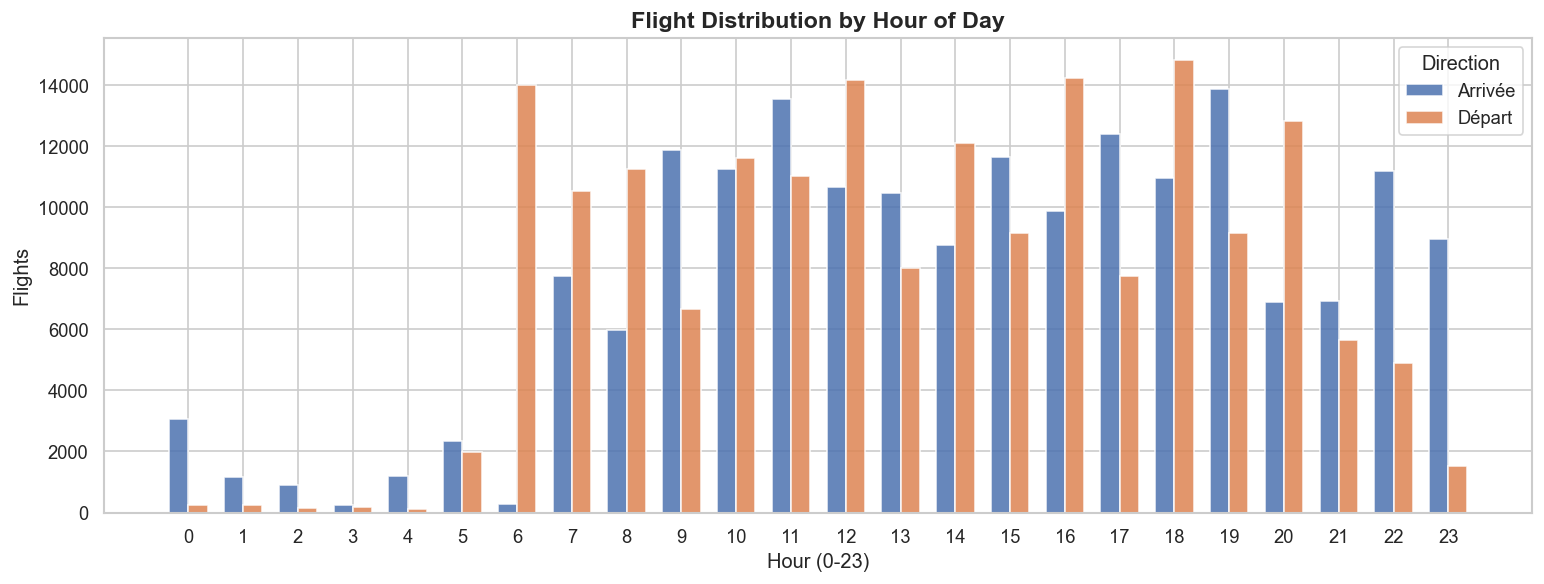

In [8]:
hourly = df.groupby(['Hour','Direction']).size().reset_index(name='count')
fig, ax = plt.subplots(figsize=(13, 5))
directions = hourly['Direction'].unique()
offsets = {d: i*0.35 - 0.175 for i, d in enumerate(directions)}
for direction, grp in hourly.groupby('Direction'):
    ax.bar(grp['Hour'] + offsets[direction], grp['count'],
           width=0.35, label=direction, alpha=0.85)
ax.set_title('Flight Distribution by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour (0-23)'); ax.set_ylabel('Flights'); ax.set_xticks(range(0,24))
ax.legend(title='Direction'); plt.tight_layout()
plt.savefig(OUT_DIR / '04_flights_by_hour.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Flights by terminal

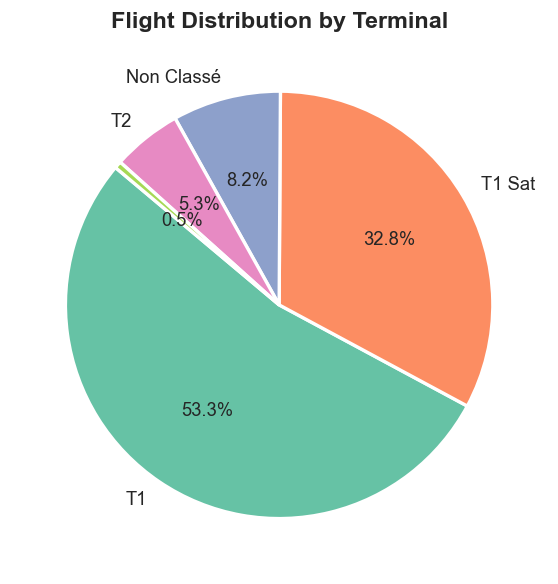

In [9]:
terminal_counts = df['Terminal'].value_counts().dropna()
fig, ax = plt.subplots(figsize=(9, 5))
ax.pie(terminal_counts, labels=terminal_counts.index, autopct='%1.1f%%',
       startangle=140, colors=sns.color_palette('Set2', len(terminal_counts)),
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Flight Distribution by Terminal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / '05_by_terminal.png', bbox_inches='tight', dpi=150)
plt.show()


## 9. Top 15 origin airports

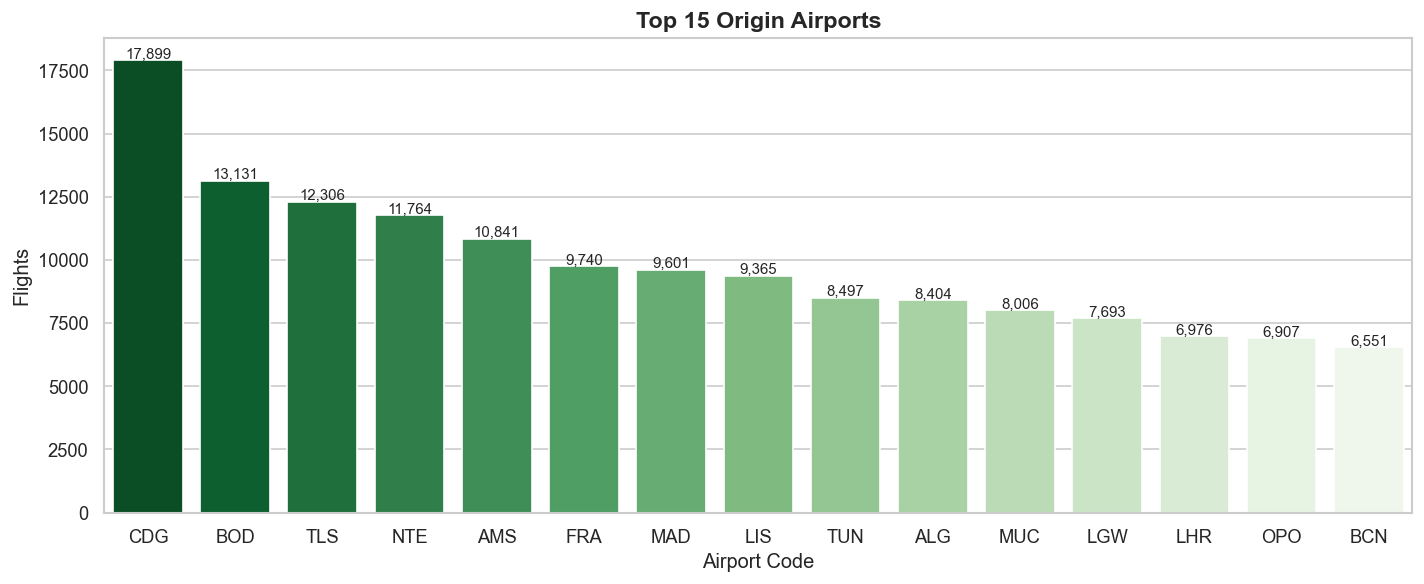

In [10]:
top_origins = df['AirportOrigin'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=top_origins.index, y=top_origins.values, palette='Greens_r', ax=ax)
ax.set_title('Top 15 Origin Airports', fontsize=14, fontweight='bold')
ax.set_xlabel('Airport Code'); ax.set_ylabel('Flights')
for i, v in enumerate(top_origins.values):
    ax.text(i, v + 80, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / '06_top_origin_airports.png', bbox_inches='tight', dpi=150)
plt.show()


## 10. Delay analysis

Flights with delay: 52,991 / 364,623 (14.5%)


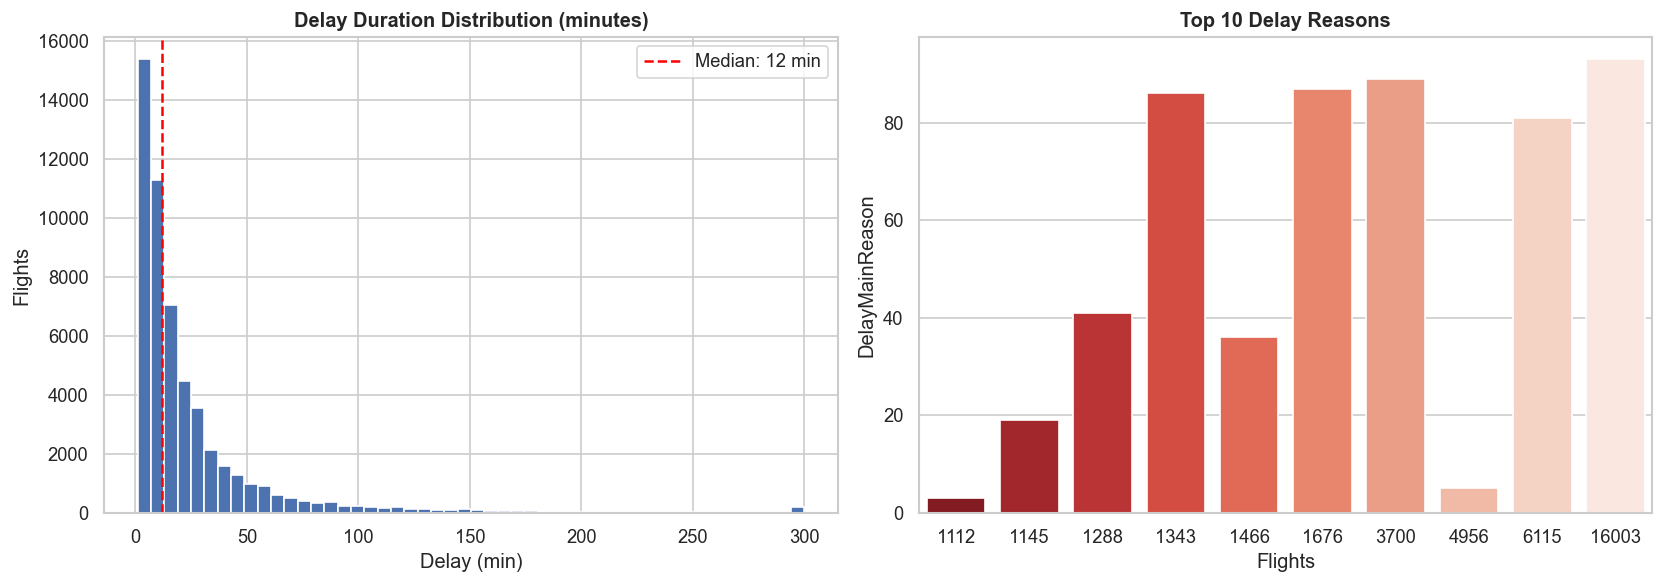

In [11]:
delay_col = "DelayMainReasonDuration"
df["_delay_num"] = pd.to_numeric(df[delay_col], errors="coerce")
df_delay = df[df["_delay_num"].notna() & (df["_delay_num"] > 0)].copy()
df_delay[delay_col] = df_delay["_delay_num"].astype(float)
print(f"Flights with delay: {len(df_delay):,} / {len(df):,} ({len(df_delay)/len(df)*100:.1f}%)")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_delay[delay_col].clip(upper=300), bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Delay Duration Distribution (minutes)", fontweight="bold")
axes[0].set_xlabel("Delay (min)"); axes[0].set_ylabel("Flights")
axes[0].axvline(df_delay[delay_col].median(), color="red", linestyle="--",
                label=f"Median: {df_delay[delay_col].median():.0f} min")
axes[0].legend()
top_reasons = df_delay["DelayMainReason"].value_counts().head(10)
sns.barplot(y=top_reasons.index, x=top_reasons.values, palette="Reds_r", ax=axes[1])
axes[1].set_title("Top 10 Delay Reasons", fontweight="bold")
axes[1].set_xlabel("Flights")
plt.tight_layout()
plt.savefig(OUT_DIR / '07_delay_analysis.png', bbox_inches='tight', dpi=150)
plt.show()


---
## 11. NbPax — distribution

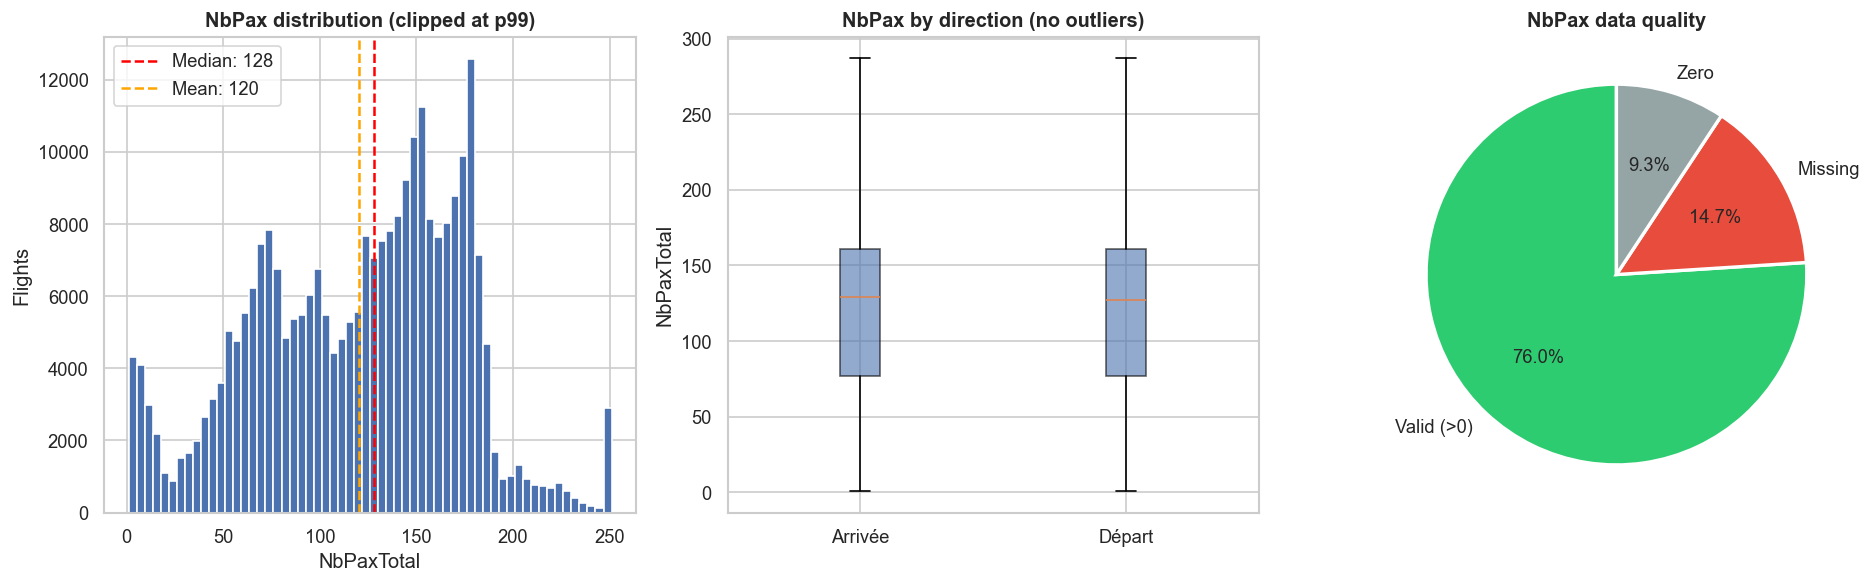

Total flights : 364,623
NbPax valid   : 277,154  (76.0%)
NbPax missing : 53,587  (14.7%)
NbPax = 0     : 33,882  (9.3%)


In [12]:
df['NbPaxTotal'] = pd.to_numeric(df['NbPaxTotal'], errors='coerce')
pax = df['NbPaxTotal'].dropna()
pax_valid = pax[pax > 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(pax_valid.clip(upper=pax_valid.quantile(0.99)), bins=60,
             color='#4C72B0', edgecolor='white')
axes[0].axvline(pax_valid.median(), color='red', linestyle='--',
                label=f'Median: {pax_valid.median():.0f}')
axes[0].axvline(pax_valid.mean(), color='orange', linestyle='--',
                label=f'Mean: {pax_valid.mean():.0f}')
axes[0].set_title('NbPax distribution (clipped at p99)', fontweight='bold')
axes[0].set_xlabel('NbPaxTotal'); axes[0].set_ylabel('Flights')
axes[0].legend()

# Boxplot by direction
dir_pax = df[df['NbPaxTotal'] > 0].groupby('Direction')['NbPaxTotal'].apply(list)
axes[1].boxplot([v for v in dir_pax], tick_labels=dir_pax.index.tolist(),
                showfliers=False, patch_artist=True,
                boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[1].set_title('NbPax by direction (no outliers)', fontweight='bold')
axes[1].set_ylabel('NbPaxTotal')

# % flights with NbPax missing
missing_pct = df['NbPaxTotal'].isna().mean() * 100
zero_pct    = (df['NbPaxTotal'] == 0).mean() * 100
valid_pct   = 100 - missing_pct - zero_pct
wedge_labels = ['Valid (>0)', 'Missing', 'Zero']
wedge_vals   = [valid_pct, missing_pct, zero_pct]
axes[2].pie(wedge_vals, labels=wedge_labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#95a5a6'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('NbPax data quality', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / '08_nbpax_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Total flights : {len(df):,}')
print(f'NbPax valid   : {(df["NbPaxTotal"] > 0).sum():,}  ({valid_pct:.1f}%)')
print(f'NbPax missing : {df["NbPaxTotal"].isna().sum():,}  ({missing_pct:.1f}%)')
print(f'NbPax = 0     : {(df["NbPaxTotal"] == 0).sum():,}  ({zero_pct:.1f}%)')


## 12. NbPax — temporal patterns

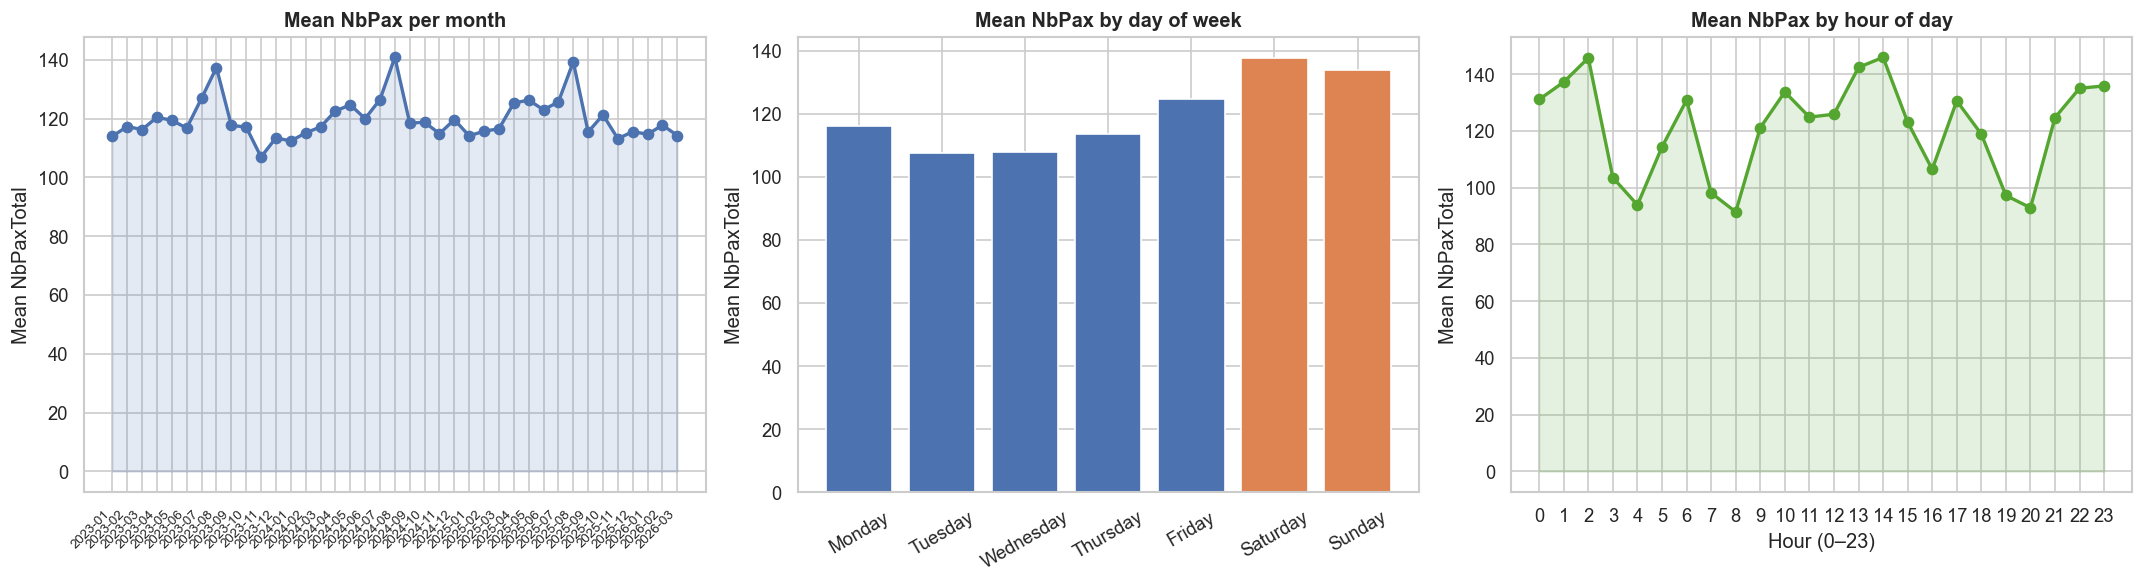

In [13]:
df_pax = df[df['NbPaxTotal'] > 0].copy()
df_pax['DayOfWeek'] = df_pax['LTScheduledDatetime'].dt.day_name()

WEEKDAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Monthly mean NbPax
monthly_pax = df_pax.groupby('Month')['NbPaxTotal'].mean().sort_index()
axes[0].plot(monthly_pax.index, monthly_pax.values, marker='o', color='#4C72B0', linewidth=2)
axes[0].fill_between(range(len(monthly_pax)), monthly_pax.values, alpha=0.15, color='#4C72B0')
axes[0].set_xticks(range(len(monthly_pax)))
axes[0].set_xticklabels(monthly_pax.index, rotation=45, ha='right', fontsize=8)
axes[0].set_title('Mean NbPax per month', fontweight='bold')
axes[0].set_ylabel('Mean NbPaxTotal')

# By day of week
dow_pax = df_pax.groupby('DayOfWeek')['NbPaxTotal'].mean().reindex(WEEKDAY_ORDER)
colors_dow = ['#DD8452' if d in ['Saturday','Sunday'] else '#4C72B0' for d in WEEKDAY_ORDER]
axes[1].bar(WEEKDAY_ORDER, dow_pax.values, color=colors_dow, edgecolor='white')
axes[1].set_title('Mean NbPax by day of week', fontweight='bold')
axes[1].set_ylabel('Mean NbPaxTotal')
axes[1].tick_params(axis='x', rotation=30)

# By hour of day
hour_pax = df_pax.groupby('Hour')['NbPaxTotal'].mean()
axes[2].plot(hour_pax.index, hour_pax.values, marker='o', color='#55A630', linewidth=2)
axes[2].fill_between(hour_pax.index, hour_pax.values, alpha=0.15, color='#55A630')
axes[2].set_title('Mean NbPax by hour of day', fontweight='bold')
axes[2].set_xlabel('Hour (0–23)'); axes[2].set_ylabel('Mean NbPaxTotal')
axes[2].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig(OUT_DIR / '09_nbpax_temporal.png', bbox_inches='tight', dpi=150)
plt.show()


## 13. NbPax — by airline

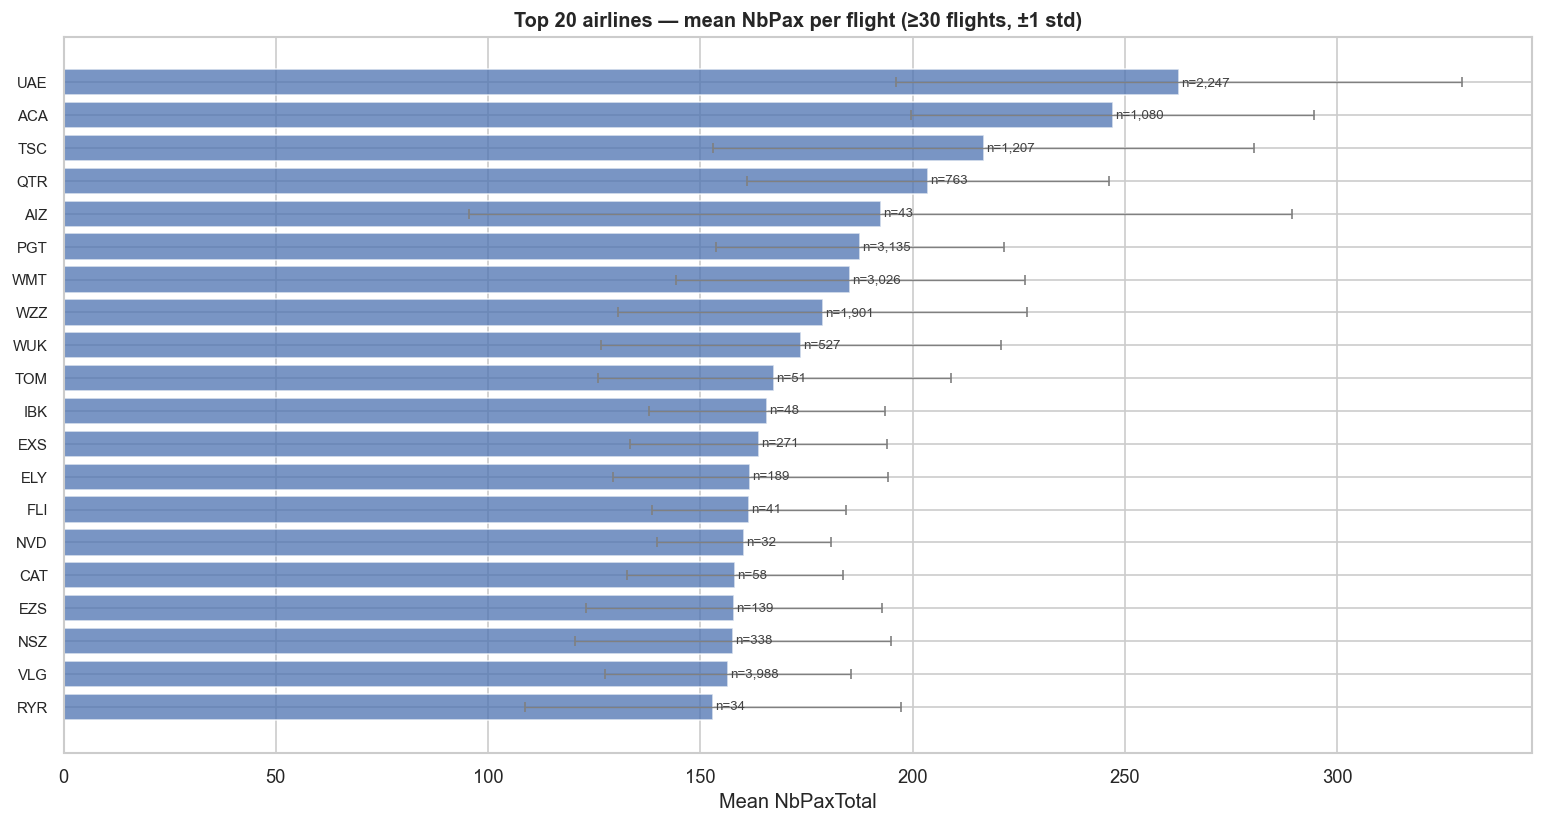

In [14]:
airline_stats = (
    df_pax.groupby('airlineOACICode')['NbPaxTotal']
    .agg(mean='mean', std='std', count='count')
    .query('count >= 30')
    .sort_values('mean', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(13, 7))
y_pos = range(len(airline_stats))
ax.barh(y_pos, airline_stats['mean'], xerr=airline_stats['std'].fillna(0),
        color='#4C72B0', alpha=0.75, edgecolor='white',
        error_kw=dict(ecolor='gray', capsize=3, linewidth=0.8))
ax.set_yticks(y_pos)
ax.set_yticklabels(airline_stats.index.tolist(), fontsize=9)
ax.invert_yaxis()
ax.set_title('Top 20 airlines — mean NbPax per flight (≥30 flights, ±1 std)', fontweight='bold')
ax.set_xlabel('Mean NbPaxTotal')
for i, (mean_val, cnt) in enumerate(zip(airline_stats['mean'], airline_stats['count'])):
    ax.text(mean_val + 0.5, i, f'n={cnt:,}', va='center', fontsize=8, color='#444')
plt.tight_layout()
plt.savefig(OUT_DIR / '10_nbpax_by_airline.png', bbox_inches='tight', dpi=150)
plt.show()


## 14. NbPax — by aircraft type

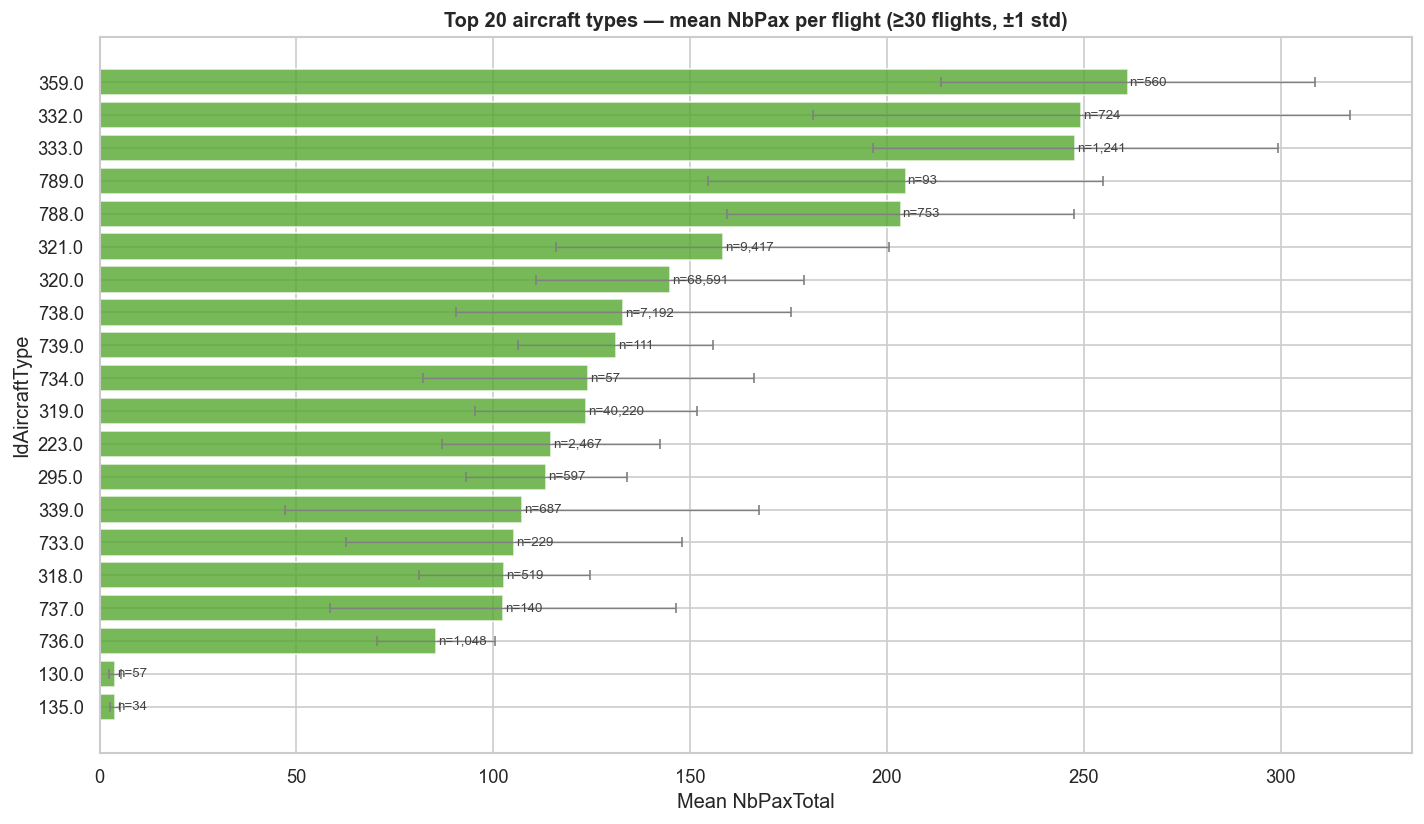

In [15]:
df_pax['IdAircraftType'] = pd.to_numeric(df_pax['IdAircraftType'], errors='coerce')

aircraft_stats = (
    df_pax.groupby('IdAircraftType')['NbPaxTotal']
    .agg(mean='mean', std='std', count='count')
    .query('count >= 30')
    .sort_values('mean', ascending=False)
    .head(20)
    .sort_values('mean')
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(aircraft_stats.index.astype(str), aircraft_stats['mean'],
        xerr=aircraft_stats['std'].fillna(0),
        color='#55A630', alpha=0.8, edgecolor='white',
        error_kw=dict(ecolor='gray', capsize=3, linewidth=0.8))
for i, (mean_val, cnt) in enumerate(zip(aircraft_stats['mean'], aircraft_stats['count'])):
    ax.text(mean_val + 0.5, i, f'n={cnt:,}', va='center', fontsize=8, color='#444')
ax.set_title('Top 20 aircraft types — mean NbPax per flight (≥30 flights, ±1 std)', fontweight='bold')
ax.set_xlabel('Mean NbPaxTotal')
ax.set_ylabel('IdAircraftType')
plt.tight_layout()
plt.savefig(OUT_DIR / '11_nbpax_by_aircraft.png', bbox_inches='tight', dpi=150)
plt.show()


## 15. NbPax — by terminal & traffic type

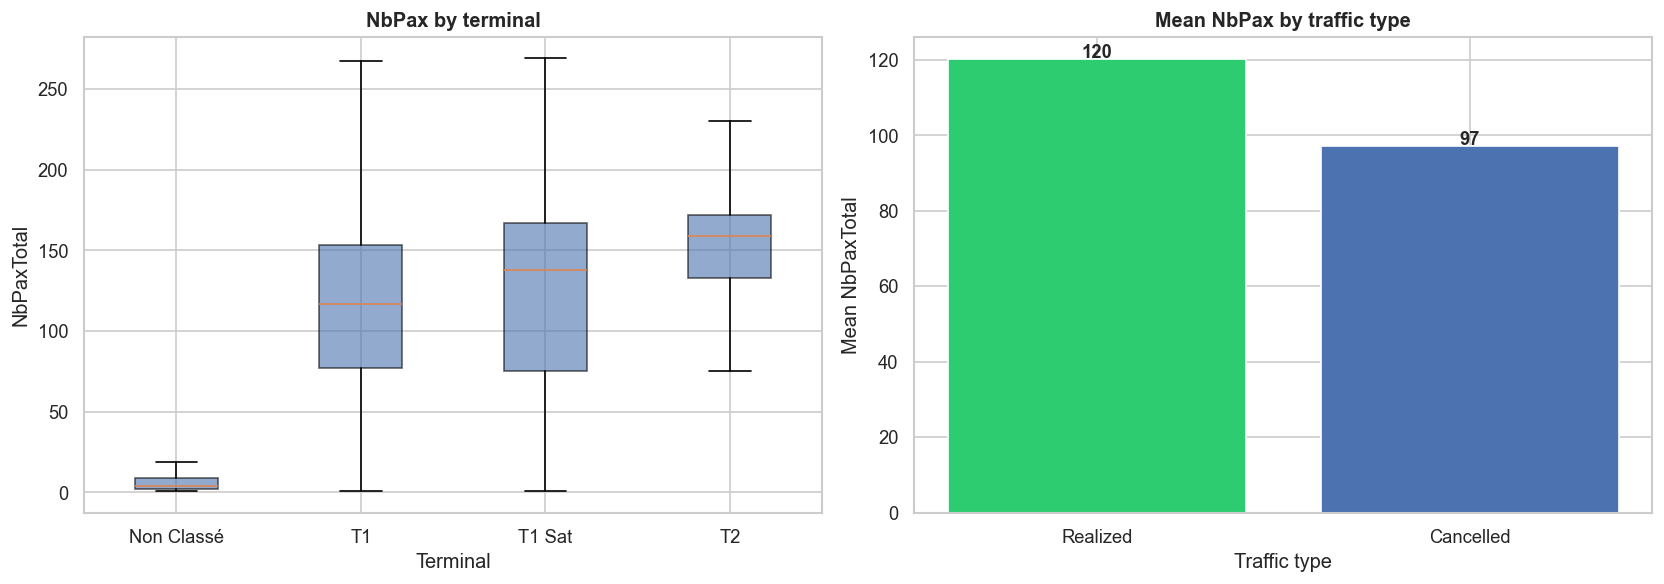

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NbPax by terminal — boxplot
terminals = df_pax['Terminal'].dropna().unique()
terminal_data = [df_pax[df_pax['Terminal'] == t]['NbPaxTotal'].values for t in sorted(terminals)]
bp = axes[0].boxplot(terminal_data, tick_labels=sorted(terminals),
                     showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#4C72B0'); patch.set_alpha(0.6)
axes[0].set_title('NbPax by terminal', fontweight='bold')
axes[0].set_xlabel('Terminal'); axes[0].set_ylabel('NbPaxTotal')

# NbPax by traffic type
TRAFIC_LABELS = {'0': 'Cancelled', '1': 'Realized', '2': 'Scheduled'}
df_pax['TraficLabel'] = df_pax['IdTraficType'].astype(str).map(TRAFIC_LABELS).fillna('Other')
trafic_mean = df_pax.groupby('TraficLabel')['NbPaxTotal'].mean().sort_values(ascending=False)
colors_trafic = ['#2ecc71', '#4C72B0', '#e74c3c', '#95a5a6']
axes[1].bar(trafic_mean.index, trafic_mean.values,
            color=colors_trafic[:len(trafic_mean)], edgecolor='white')
axes[1].set_title('Mean NbPax by traffic type', fontweight='bold')
axes[1].set_xlabel('Traffic type'); axes[1].set_ylabel('Mean NbPaxTotal')
for i, v in enumerate(trafic_mean.values):
    axes[1].text(i, v + 0.5, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / '12_nbpax_terminal_trafic.png', bbox_inches='tight', dpi=150)
plt.show()


## 16. NbPax — top 20 routes (origin × direction)

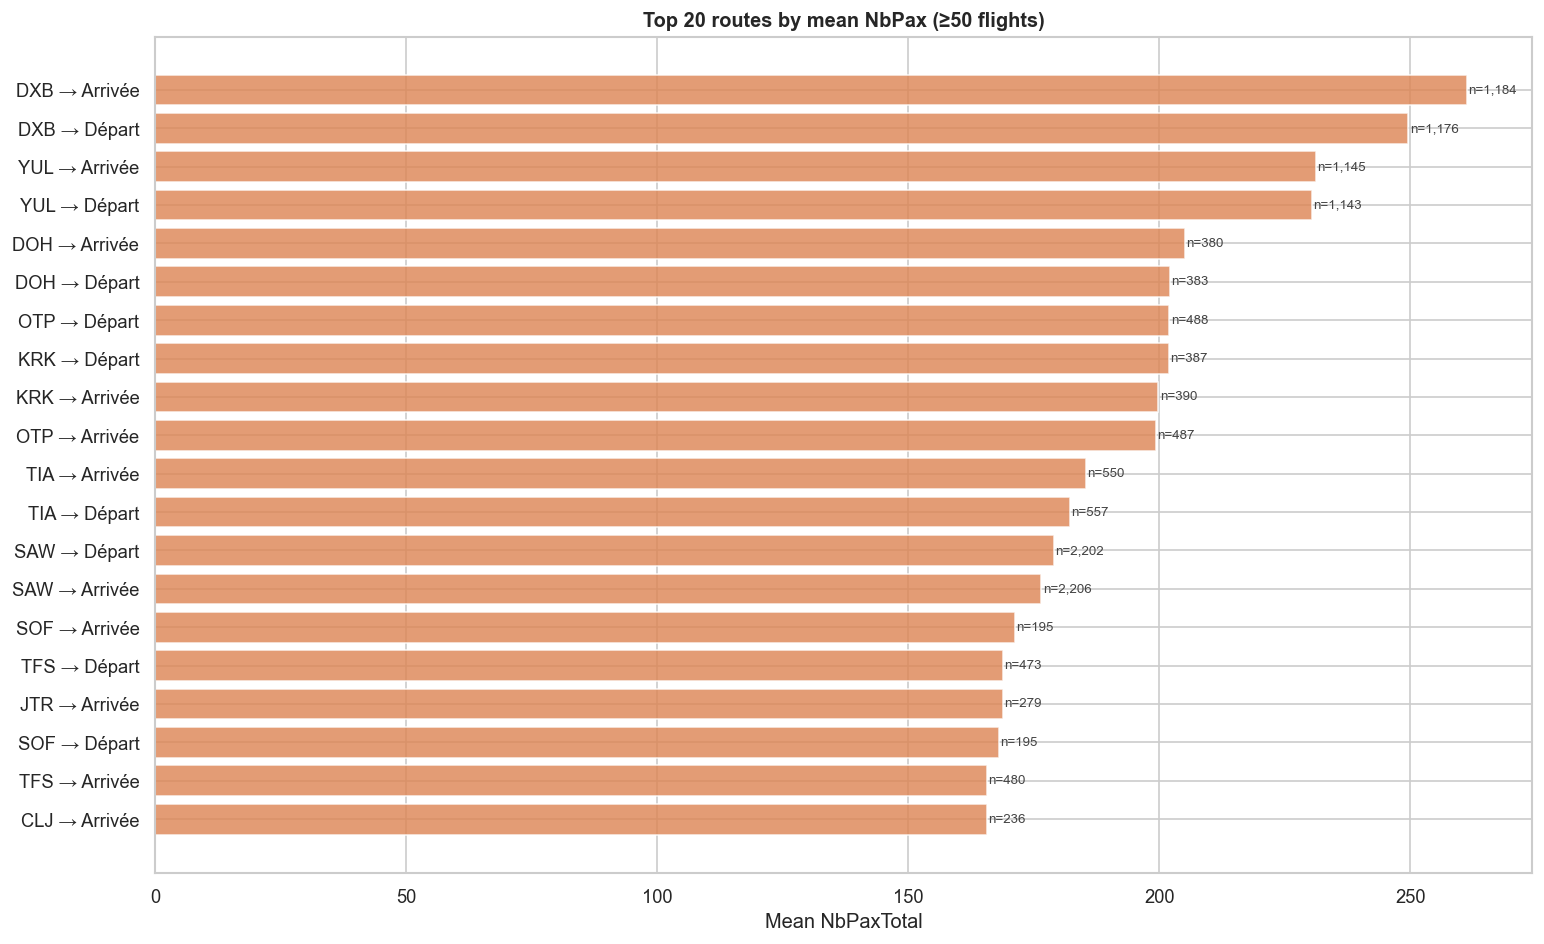

In [17]:
route_stats = (
    df_pax.assign(Route=df_pax['AirportOrigin'].astype(str) + ' → ' + df_pax['Direction'].astype(str))
    .groupby('Route')['NbPaxTotal']
    .agg(mean='mean', count='count')
    .query('count >= 50')
    .sort_values('mean', ascending=False)
    .head(20)
    .sort_values('mean')
)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(route_stats.index, route_stats['mean'],
               color='#DD8452', alpha=0.8, edgecolor='white')
for bar, cnt in zip(bars, route_stats['count']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'n={cnt:,}', va='center', fontsize=8, color='#444')
ax.set_title('Top 20 routes by mean NbPax (≥50 flights)', fontweight='bold')
ax.set_xlabel('Mean NbPaxTotal')
plt.tight_layout()
plt.savefig(OUT_DIR / '13_nbpax_top_routes.png', bbox_inches='tight', dpi=150)
plt.show()
